In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
###--------------------NOTE--------------------------------###
###This code is just a copy from the python Package: miepython
###See https://miepython.readthedocs.io/en/latest/

from copy import Error
from logging import raiseExceptions
def _Lentz_Dn(z, N):
    """
    Compute the logarithmic derivative of the Ricatti-Bessel function.

    Args:
        z: function argument
        N: order of Ricatti-Bessel function

    Returns:
        This returns the Ricatti-Bessel function of order N with argument z
        using the continued fraction technique of Lentz, Appl. Opt., 15,
        668-671, (1976).
    """
    zinv = 2.0 / z
    alpha = (N + 0.5) * zinv
    aj = -(N + 1.5) * zinv
    alpha_j1 = aj + 1 / alpha
    alpha_j2 = aj
    ratio = alpha_j1 / alpha_j2
    runratio = alpha * ratio

    while np.abs(np.abs(ratio) - 1.0) > 1e-12:
        aj = zinv - aj
        alpha_j1 = 1.0 / alpha_j1 + aj
        alpha_j2 = 1.0 / alpha_j2 + aj
        ratio = alpha_j1 / alpha_j2
        zinv *= -1
        runratio = ratio * runratio

    return -N / z + runratio


def _D_downwards(z, N, D):
    """
    Compute the logarithmic derivative by downwards recurrence.

    Args:
        z: function argument
        N: order of Ricatti-Bessel function
        D: gets filled with the Ricatti-Bessel function values for orders
           from 0 to N for an argument z using the downwards recurrence relations.
    """
    last_D = _Lentz_Dn(z, N)
    for n in range(N, 0, -1):
        last_D = n / z - 1.0 / (last_D + n / z)
        D[n - 1] = last_D


def _D_upwards(z, N, D):
    """
    Compute the logarithmic derivative by upwards recurrence.

    Args:
        z: function argument
        N: order of Ricatti-Bessel function
        D: gets filled with the Ricatti-Bessel function values for orders
           from 0 to N for an argument z using the upwards recurrence relations.
    """
    exp = np.exp(-2j * z)
    D[1] = -1 / z + (1 - exp) / ((1 - exp) / z - 1j * (1 + exp))
    for n in range(2, N):
        D[n] = 1 / (n / z - D[n - 1]) - n / z


def _D_calc(m, x, N):
    """
    Compute the logarithmic derivative using best method.

    Args:
        m: the complex index of refraction of the sphere
        x: the size parameter of the sphere
        N: order of Ricatti-Bessel function

    Returns:
        The values of the Ricatti-Bessel function for orders from 0 to N.
    """
    n = m.real
    kappa = np.abs(m.imag)
    D = np.zeros(N, dtype=np.complex128)

    if n < 1 or n > 10 or kappa > 10 or x * kappa >= 3.9 - 10.8 * n + 13.78 * n**2:
        _D_downwards(m * x, N, D)
    else:
        _D_upwards(m * x, N, D)
    return D


def _mie_An_Bn(m, x):
    """
    Compute arrays of Mie coefficients A and B for a sphere.

    This estimates the size of the arrays based on Wiscombe's formula. The length
    of the arrays is chosen so that the error when the series are summed is
    around 1e-6.

    Args:
        m: the complex index of refraction of the sphere
        x: the size parameter of the sphere

    Returns:
        a, b: arrays of Mie coefficents An and Bn
    """
    nstop = int(x + 4.05 * x**0.33333 + 2.0) + 1
    a = np.zeros(nstop - 1, dtype=np.complex128)
    b = np.zeros(nstop - 1, dtype=np.complex128)

    psi_nm1 = np.sin(x)                   # nm1 = n-1 = 0
    psi_n = psi_nm1 / x - np.cos(x)       # n = 1
    xi_nm1 = complex(psi_nm1, np.cos(x))
    xi_n = complex(psi_n, np.cos(x) / x + np.sin(x))

    if m.real > 0.0:
        D = _D_calc(m, x, nstop + 1)

        for n in range(1, nstop):
            temp = D[n] / m + n / x
            a[n - 1] = (temp * psi_n - psi_nm1) / (temp * xi_n - xi_nm1)
            temp = D[n] * m + n / x
            b[n - 1] = (temp * psi_n - psi_nm1) / (temp * xi_n - xi_nm1)
            xi = (2 * n + 1) * xi_n / x - xi_nm1
            xi_nm1 = xi_n
            xi_n = xi
            psi_nm1 = psi_n
            psi_n = xi_n.real

    else:
        for n in range(1, nstop):
            a[n - 1] = (n * psi_n / x - psi_nm1) / (n * xi_n / x - xi_nm1)
            b[n - 1] = psi_n / xi_n
            xi = (2 * n + 1) * xi_n / x - xi_nm1
            xi_nm1 = xi_n
            xi_n = xi
            psi_nm1 = psi_n
            psi_n = xi_n.real

    return a, b


def _small_mie(m, x):
    """
    Calculate the efficiencies for a small sphere.

    Typically used for small spheres where x<0.1

    Args:
        m: the complex index of refraction of the sphere
        x: the size parameter of the sphere

    Returns:
        qext: the total extinction efficiency
        qsca: the scattering efficiency
        qback: the backscatter efficiency
        g: the average cosine of the scattering phase function
    """
    m2 = m * m
    x2 = x * x

    D = m2 + 2 + (1 - 0.7 * m2) * x2
    D -= (8 * m**4 - 385 * m2 + 350) * x**4 / 1400.0
    D += 2j * (m2 - 1) * x**3 * (1 - 0.1 * x2) / 3
    ahat1 = 2j * (m2 - 1) / 3 * (1 - 0.1 * x2 + (4 * m2 + 5) * x**4 / 1400) / D

    bhat1 = 1j * x2 * (m2 - 1) / 45 * (1 + (2 * m2 - 5) / 70 * x2)
    bhat1 /= 1 - (2 * m2 - 5) / 30 * x2

    ahat2 = 1j * x2 * (m2 - 1) / 15 * (1 - x2 / 14)
    ahat2 /= 2 * m2 + 3 - (2 * m2 - 7) / 14 * x2

    T = np.abs(ahat1)**2 + np.abs(bhat1)**2 + 5 / 3 * np.abs(ahat2)**2
    temp = ahat2 + bhat1
    g = (ahat1 * temp.conjugate()).real / T

    qsca = 6 * x**4 * T

    if m.imag == 0:
        qext = qsca
    else:
        qext = 6 * x * (ahat1 + bhat1 + 5 * ahat2 / 3).real

    return [qext, qsca]


def _mie_scalar(m, x):
    """
    Calculate the efficiencies for a sphere when both m and x are scalars.

    Args:
        m: the complex index of refraction of the sphere
        x: the size parameter of the sphere

    Returns:
        qext: the total extinction efficiency
        qsca: the scattering efficiency
    """
    if m.real == 0 and x < 0.1:
      raise RuntimeError('We are not woring on the conducting material!')

    elif m.real > 0.0 and np.abs(m) * x < 0.1:
        qext, qsca = _small_mie(m, x)

    else:
        a, b = _mie_An_Bn(m, x)

        nmax = len(a)
        n = np.arange(1, nmax + 1)
        cn = 2.0 * n + 1.0

        qext = 2 * np.sum(cn * (a.real + b.real)) / x**2
        qsca = qext

        if m.imag != 0:
            qsca = 2 * np.sum(cn * (np.abs(a)**2 + np.abs(b)**2)) / x**2

        c1n = n * (n + 2) / (n + 1)
        c2n = cn / n / (n + 1)

    return [qext, qsca]


def mie(m, x):
    """
    Calculate the efficiencies for a sphere where m or x may be arrays.

    Args:
        m: the complex index of refraction of the sphere
            complex form: m = n - i*k, where n is the real part and k is the imaginary part
        x: the size parameter of the sphere
            x= 2 * pi * a / lambda, where a is the radius of the sphere and lambda is the wavelength of the incident light

    Returns:
        qext: the total extinction efficiency
        qsca: the scattering efficiency
    """
    mm = m
    xx = x

    if np.isscalar(m) and np.isscalar(x):
        return _mie_scalar(mm, xx)

    if np.isscalar(m):
        mlen = 0
    else:
        mlen = len(m)

    if np.isscalar(x):
        xlen = 0
    else:
        xlen = len(x)

    if xlen > 0 and mlen > 0 and xlen != mlen:
        raise RuntimeError('m and x arrays to mie must be same length')

    thelen = max(xlen, mlen)
    qext = np.empty(thelen, dtype=np.float64)
    qsca = np.empty(thelen, dtype=np.float64)

    for i in range(thelen):
        if mlen > 0:
            mm = m[i]

        if xlen > 0:
            xx = x[i]

        qext[i], qsca[i] = _mie_scalar(mm, xx)

    return [qext, qsca]

An example of how to use Mie theory for water material

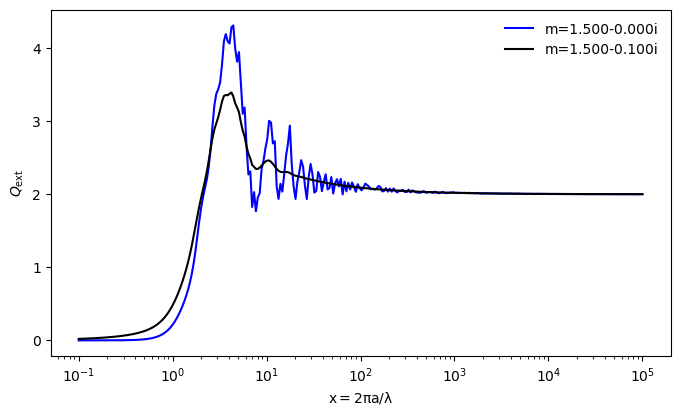

In [ ]:
plt.figure(figsize=(8,4.5))

##no absorption
m = 1.5 -0.0j
x = np.logspace(-1, 5, 300)  # in microns
qext, qsca = mie(m,x)
qabs = qext-qsca
plt.semilogx(x, qext, 'b-', label='m=%.3f-%.3fi'%(m.real,abs(m.imag)))

#quite alot absorption
m = 1.5-0.1j
x = np.logspace(-1, 5, 300)  # in microns
qext, qsca = mie(m,x)
qabs = qext-qsca

plt.semilogx(x, qext, 'k-', label='m=%.3f-%.3fi'%(m.real,abs(m.imag)))
plt.xlabel('$\\sf x=2\pi a/\lambda$')
plt.ylabel('$Q_{\\sf ext}$')
plt.legend(frameon=False)
plt.show()

Computing the absorption coefficient for Olivine dust (MgFeSiO4)
The refractive index is given in astrosil-Draine2003.lnk


In [ ]:
###--------------------YOUR CODE--------------------------------###
refrac_sil = np.loadtxt('astrosil-Draine2003.lnk',skiprows=14)
w=refrac_sil[:,0] #wavelength in micron
m=refrac_sil[:,1] #real part of the refractive index
n=refrac_sil[:,2] #imaginary part of the refractive index

# you can continue here ...